# 51.2 · Model and runtime choices

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain model and runtime choices using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[49 · Model Optimization](../../49-model-optimization/README.md), [50 · Computer Vision Deployment](../../50-computer-vision-deployment/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

Edge AI runs perception near the sensor on constrained hardware. Memory, power, thermal behavior and supported operators can matter as much as model size. Target-device measurements are necessary because desktop CPU results do not predict every edge accelerator.

## 2. Intuition

Mobile architectures use operations designed for limited compute, but the fastest model depends on runtime support and memory access. Quantization, operator fusion and hardware accelerators introduce compatibility constraints. A graph that falls back to CPU for unsupported operations may lose the expected speed advantage.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 51
LESSON = 1
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
M=HWCb
$$

M is buffer size in bytes, H,W spatial dimensions, C channels and b bytes per element. A 640×480 RGB uint8 image uses 921600 bytes, excluding object overhead and copies.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
height, width, channels, bytes_per_element = 480, 640, 3, 1
size = height * width * channels * bytes_per_element
assert size == 921600
print(size)

921600


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

The lab resizes one generated image, runs Canny repeatedly, records buffer size and compares resized edge masks to the full-resolution algorithm output.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def edge(lesson=0, seed=42, amount=1.0):
    image = picture(seed, size=192)
    reference = cv2.Canny(cv2.cvtColor(image, cv2.COLOR_RGB2GRAY), 80, 160) > 0
    errors = []
    latency = []
    sizes = []
    for size in (192, 144, 96, 48):
        samples = []
        for _ in range(8):
            start = time.perf_counter()
            small = cv2.resize(image, (size, size), interpolation=cv2.INTER_AREA)
            edges = cv2.Canny(cv2.cvtColor(small, cv2.COLOR_RGB2GRAY), 80, 160)
            samples.append((time.perf_counter() - start) * 1000)
        restored = cv2.resize(edges, (192, 192), interpolation=cv2.INTER_NEAREST) > 0
        union = (reference | restored).sum()
        errors.append(float((reference & restored).sum() / max(union, 1)))
        latency.append(float(np.median(samples)))
        sizes.append(small.nbytes)
    return Result(
        "51 · Resolution, memory and edge fidelity",
        {"Full-resolution RGB": image, "Small edge map resized for display": restored},
        curves={
            "Input side→median processing milliseconds": np.column_stack(
                [[192, 144, 96, 48], latency]
            ),
            "Input side→edge IoU": np.column_stack([[192, 144, 96, 48], errors]),
        },
        metrics={
            "resolutions": [192, 144, 96, 48],
            "rgb_buffer_bytes": sizes,
            "median_processing_ms": latency,
            "edge_iou": errors,
        },
        notes="Local CPU measurements are not edge-device benchmarks. Edge IoU compares to the full-resolution algorithm, not annotated ground truth. Quantization, power and device runtimes require separate target-device measurements.",
    )

{
  "resolutions": [
    192,
    144,
    96,
    48
  ],
  "rgb_buffer_bytes": [
    110592,
    62208,
    27648,
    6912
  ],
  "median_processing_ms": [
    0.05583899996963737,
    0.2584174999356037,
    0.0383875001261913,
    0.05989999999655993
  ],
  "edge_iou": [
    1.0,
    0.5905143620574482,
    0.3294609665427509,
    0.12262658227848101
  ]
}
Local CPU measurements are not edge-device benchmarks. Edge IoU compares to the full-resolution algorithm, not annotated ground truth. Quantization, power and device runtimes require separate target-device measurements.


## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/engineering.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.engineering import quantize_symmetric

display(Code(inspect.getsource(quantize_symmetric), language="python"))

def quantize_symmetric(weights):
    """Per-tensor signed int8 quantization and floating reconstruction."""
    scale = max(float(np.max(np.abs(weights))) / 127, np.finfo(float).eps)
    quantized = np.clip(np.rint(weights / scale), -127, 127).astype(np.int8)
    return quantized, scale, quantized.astype(np.float32) * scale

## 8. Experiment

Choose a small-object size and reduce resolution until it disappears. Compare the memory saving with the task-specific quality loss.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "resolutions": [
      192,
      144,
      96,
      48
    ],
    "rgb_buffer_bytes": [
      110592,
      62208,
      27648,
      6912
    ],
    "median_processing_ms": [
      0.05583899996963737,
      0.2584174999356037,
      0.0383875001261913,
      0.05989999999655993
    ],
    "edge_iou": [
      1.0,
      0.5905143620574482,
      0.3294609665427509,
      0.12262658227848101
    ]
  },
  "second_seed": {
    "resolutions": [
      192,
      144,
      96,
      48
    ],
    "rgb_buffer_bytes": [
      110592,
      62208,
      27648,
      6912
    ],
    "median_processing_ms": [
      0.05024000006415008,
      0.24496799983353412,
      0.03503700008877786,
      0.06104649969529419
    ],
    "edge_iou": [
      1.0,
      0.5619295958279009,
      0.3184331797235023,
      0.12017960908610671
    ]
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

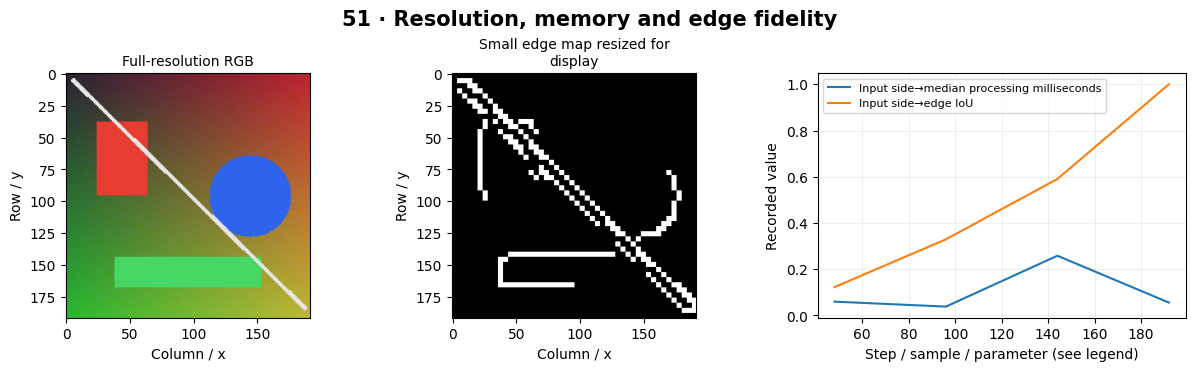

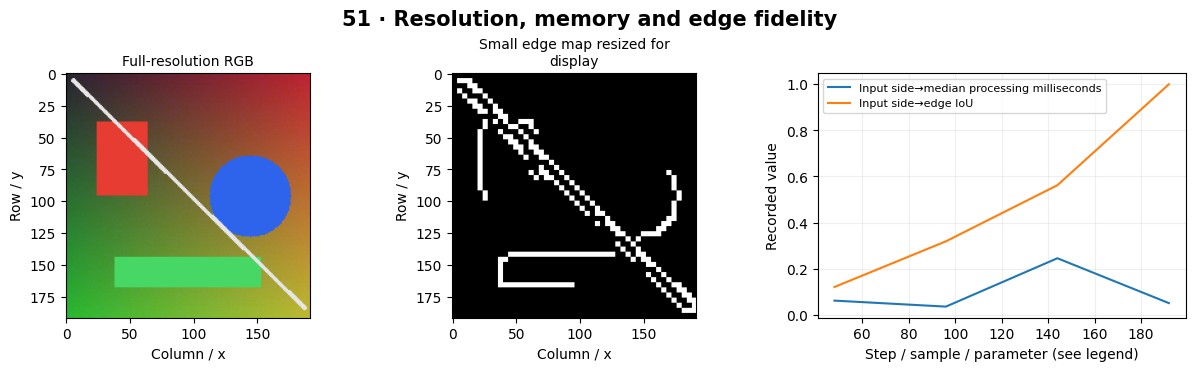

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **Edge Inference Benchmark**. Measure performance under actual device constraints. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

A smaller model file may still allocate large activations. Cold-start and thermally throttled timings answer different operational questions.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Choose a small-object size and reduce resolution until it disappears. Compare the memory saving with the task-specific quality loss.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Profile one model on a real edge device and publish a reproducible table including temperature, power mode and image resolution.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

Mobile architectures use operations designed for limited compute, but the fastest model depends on runtime support and memory access. Quantization, operator fusion and hardware accelerators introduce compatibility constraints. A graph that falls back to CPU for unsupported operations may lose the expected speed advantage.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

Continue with **Target-device evaluation** in this chapter.

[Primary reference](https://onnxruntime.ai/docs/performance/) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)